Classifier-only
- "loss" , "val_loss" (CrossEntropy)
- "accuracy" / "val_accuracy"


Autoencoder-only
- "loss", "val_loss" (reconstruction loss - MSE)
- "mae" / "val_mae" (if compiled)

Multi-output
- "loss" (total weighted loss, w_mse\*MSE + w_ce\*CrossEntropy)
- "reconstruction_loss", "val_reconstruction_loss"
- "classification_loss", "val_classification_loss"
- "val_classification_accuracy", "val_mae"

In [37]:
from Deep_Library_BCI import MultiTaskModel

mymo = MultiTaskModel(input_shape=(128,1), use_classifier=True, use_decoder=True)

2026-01-20 14:30:19.818993: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-20 14:30:19.883290: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-20 14:30:21.336172: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1768915821.923275  578751 gpu_device.cc:2020] Created device /job:lo

8 128


In [7]:
mymo.encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 128, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 128, 16)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 64, 64)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 32, 256)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 16, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           52

 Total params: 186,224 (727.44 KB)

 Trainable params: 185,296 (723.81 KB)

 Non-trainable params: 928 (3.62 KB)

In [5]:
mymo.decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 16, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 64, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 64, 64)         │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_3 (UpSampling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 128, 16)        │         3,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Conv1D)         │ (None, 128, 1)         │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,601 (850.00 KB)

 Trainable params: 217,601 (850.00 KB)

 Non-trainable params: 0 (0.00 B)

# CFM network

In [8]:


import keras

from keras import layers
CFM = keras.models.Sequential([
    layers.Conv1D(32, 5, input_shape=(160, 1), activation="relu", padding="same"),
    layers.Dropout(0.5),
    layers.Conv1D(64, 4, activation="relu"),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, activation="relu"),
    layers.MaxPooling1D(2),
    layers.Conv1D(256, 5, activation="relu", padding="same"),
    layers.Dropout(0.5),
    layers.Conv1D(128, 3, activation="relu"),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(50, activation="softsign"),
    layers.Dense(1, activation="sigmoid")
])

/home/silvia/Documents/GitHub/BCI_Project/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
CFM.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_17 (Conv1D)              │ (None, 160, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 160, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_18 (Conv1D)              │ (None, 157, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 78, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 76, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_16 (MaxPooling1D) │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 38, 256)        │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 38, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 36, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │       115,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410,981 (1.57 MB)

 Trainable params: 410,981 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

# In Utils - verify custon functions

In [11]:
sampling_hz = 250
start = 3           # seconds where to start to extract windows
start = start*sampling_hz
input_shape = 128
shift = 62          # points to shift for next window in data
num_windows = 11    # how many windows to extract from each trial

end = start + (num_windows-1)*shift + input_shape
start, 6*250, end, 62*10+128+start

(750, 1500, 1498, 1498)

## Function to extract (11?) windows (128? samples) from a single trial

In [12]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

def extract_windows(x, win_len, shift):
    # x shape: (192, 68, 1024)
    windows = sliding_window_view(x, window_shape=win_len, axis=-1)
    # windows shape: (192, 68, 1024 - win_len + 1, win_len)

    # apply hop/shift
    windows = windows[..., ::shift, :]

    return windows


x = np.random.rand(192, 68, 748)
win_len = 128 
shift = 62
windows = extract_windows(x, win_len, shift)
windows.shape

(192, 68, 11, 128)

In [ ]:
x = np.array([[ 2*i+1 for i in range(4)],[ 2*i+2 for i in range(4)]])
x = x[np.newaxis, :, :]
x = np.concatenate((x, x*10), axis=0)
x, x.shape # trials x ROIs x timepoints

(array([[[ 1,  3,  5,  7],
         [ 2,  4,  6,  8]],
 
        [[10, 30, 50, 70],
         [20, 40, 60, 80]]]),
 (2, 2, 4))

In [ ]:
winded = extract_windows(x, win_len=2, shift=1)
winded, winded.shape # trials x ROIs x windows x timepoints (len_window)

(array([[[[ 1,  3],
          [ 3,  5],
          [ 5,  7]],
 
         [[ 2,  4],
          [ 4,  6],
          [ 6,  8]]],
 
 
        [[[10, 30],
          [30, 50],
          [50, 70]],
 
         [[20, 40],
          [40, 60],
          [60, 80]]]]),
 (2, 2, 3, 2))

In [ ]:
winded.reshape(-1, winded.shape[-1]) # trials*ROIs*windows x timepoints

array([[ 1,  3],
       [ 3,  5],
       [ 5,  7],
       [ 2,  4],
       [ 4,  6],
       [ 6,  8],
       [10, 30],
       [30, 50],
       [50, 70],
       [20, 40],
       [40, 60],
       [60, 80]])

## SPLIT: Train Val Test to preserve ROIs balancing/ MI vs Rest counts

### Function to split in train test val BEFORE windowing + function to create labels

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
## inputs x,y,
train_percentage = 0.7 ;        trp=train_percentage
validation_percentage = 0.15;   vp=validation_percentage
test_percentage = 0.15;         tep = test_percentage

################## TODO ######################
# function create labels y (so i can clearly see that it is a passage)

# assegno positivi a quelli di dopo (MI) e negativi a quelli di prima (Rest)
y = np.ones((192, 68))
y[0:96, :] = -1

# assegno valore in base a ROI, da ±1 a ±68
for col in range(y.shape[1]):
    y[:, col] *= (col+1)

y = y.reshape(-1,) # da eseguire insieme al reshape dei dati
y

x = np.random.rand(192, 68, 748)

#windows = extract_windows(x, win_len, shift)
x.shape

x = x.reshape(-1,x.shape[-1],)
x.shape, y.shape

if trp + vp + tep != 1:
    raise ValueError("Train, validation, and test percentages must sum to 1.")


X_train, X_tmp, y_train, y_tmp = train_test_split(
    x, y,
    test_size=1-trp,          # 70% train, 30% temp
    stratify=y,             # preserves label balance
    random_state=42,
    shuffle=True
)


X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=vp/(vp+tep),          # 15% val, 15% test
    stratify=y_tmp,         # preserves balance again
    random_state=42,
    shuffle=True
)


((13056, 748), (13056,))

In [ ]:
1/68/2*100

0.7352941176470588

In [ ]:
for i in set(y_val):
    print(i,"\t", sum(y_val==i)/len(y_val)*100, sum(y_val==i))

1.0 	 0.7150153217568949 14
2.0 	 0.7150153217568949 14
3.0 	 0.7660878447395302 15
4.0 	 0.7150153217568949 14
5.0 	 0.7150153217568949 14
6.0 	 0.7150153217568949 14
7.0 	 0.7150153217568949 14
8.0 	 0.7660878447395302 15
9.0 	 0.7660878447395302 15
10.0 	 0.7660878447395302 15
11.0 	 0.7150153217568949 14
12.0 	 0.7150153217568949 14
13.0 	 0.7660878447395302 15
14.0 	 0.7150153217568949 14
15.0 	 0.7150153217568949 14
16.0 	 0.7150153217568949 14
17.0 	 0.7150153217568949 14
18.0 	 0.7660878447395302 15
19.0 	 0.7660878447395302 15
20.0 	 0.7660878447395302 15
21.0 	 0.7150153217568949 14
22.0 	 0.7660878447395302 15
23.0 	 0.7660878447395302 15
24.0 	 0.7150153217568949 14
25.0 	 0.7660878447395302 15
26.0 	 0.7150153217568949 14
27.0 	 0.7660878447395302 15
28.0 	 0.7660878447395302 15
29.0 	 0.7660878447395302 15
30.0 	 0.7150153217568949 14
31.0 	 0.7150153217568949 14
32.0 	 0.7660878447395302 15
33.0 	 0.7150153217568949 14
34.0 	 0.7660878447395302 15
35.0 	 0.76608784473953

### Function that take x, y. split x in many windows and then proliferate "y" in order to match X

In [ ]:
def extract_windows(x, win_len=128, shift=62):
    """ OK, verified (see Test.ipynb -> Function extract window check)"""
    # x shape: (192, 68, 748) 
    # 192 trials, 68 ROIs, 748 time points
    # 128 + 62*(11-1)  = 748

    windows = sliding_window_view(x, window_shape=win_len, axis=-1)
    # windows shape: (192, 68, 748 - win_len + 1, win_len)

    # apply hop/shift
    windows = windows[..., ::shift, :]

    return windows

win_len = 128 
shift = 62

In [81]:
X = X_test
Y = y_test

In [ ]:
X_windowed = extract_windows(X)
Y_windowed = np.repeat(Y[:, None], X_windowed.shape[1], axis=1)
X_windowed.shape, Y_windowed.shape

((1959, 11, 128), (1959, 11))

In [88]:
X_windowed_reshaped = X_windowed.reshape(-1, X_windowed.shape[-1])
Y_windowed_reshaped = Y_windowed.reshape(-1,)
X_windowed_reshaped.shape, Y_windowed_reshaped.shape

((21549, 128), (21549,))

In [ ]:
for qua in Y_windowed_reshaped:
    print(qua)

### All together - try

In [1]:
import numpy as np
from Utils import windowize, split_train_val_test
x = np.ones((192,68,748))

train,val,test = split_train_val_test(x, train_percentage=0.7, validation_percentage=0.15, test_percentage=0.15)

In [ ]:
train

(array([[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]], shape=(9139, 748)),
 array([ 40.,  30., -37., ...,  58., -10.,  18.], shape=(9139,)))

In [3]:
9139*11

100529

In [ ]:
x_train, y_train = windowize(*train)

(array([[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]], shape=(100529, 128)),
 array([40., 40., 40., ..., 18., 18., 18.], shape=(100529,)))

## Normalization - verify


In [27]:
from Utils import create_labels
from Utils import RegionWiseStandardizer
import numpy as np

scaler = RegionWiseStandardizer()
trials = 50
regions = 4

xtr = np.random.rand(trials,regions,10)
xte = np.random.rand(trials,regions,10)

xtr[:,1,:] *= 3
xte[:,1,:] *= 1

y = create_labels(trials, regions)

xtr = xtr.reshape(-1, xtr.shape[-1],order='F')
xte = xte.reshape(-1, xte.shape[-1],order='F')


y = y.reshape(-1,order='F')

xtr.shape, y.shape

((200, 10), (200,))

In [28]:
utr = scaler.fit_transform(xtr,y)

(50, 10) () ()
0.2845050207954337
(50, 10) () ()
0.8575983118947633
(50, 10) () ()
0.281470898936702
(50, 10) () ()
0.2923806440343879


In [29]:
ute = scaler.transform(xte,y)

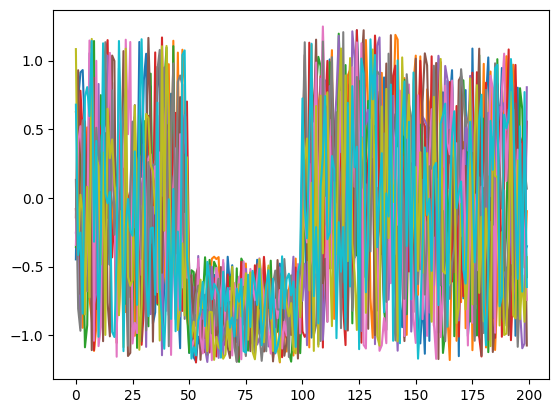

In [30]:
import matplotlib.pyplot as plt
plt.plot(ute/1.5)

## All together

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import sys
sys.path.append(os.path.abspath("../Codes"))

from Utils import freq_filter, split_train_val_test, windowize, RegionWiseStandardizer, TraceWiseStandardizer
from BCI_Library import read_subject
data_folder="../Data/"
subject = 2
DataType = "EEG"

start = 3           # seconds where to start to extract windows
sampling_hz = 250;  start = start*sampling_hz
input_shape = 128   # length of each window
shift = 62          # points to shift for next window in data
num_windows = 11    # how many windows to extract from each trial

end = start + (num_windows-1)*shift + input_shape  # seconds where to end to extract windows (1500 == 6 seconds)

epochs = 200
batch_monitor=35
latent_dim = 16
BATCH_SIZE = 512
LAST_LAYER_ACTIVATION = "sigmoid"
tanh = False


train_percentage = 0.7
validation_percentage = 0.15
test_percentage = 0.15
trp = train_percentage; vp = validation_percentage; tep = test_percentage



##########################################
# Read data - filter
# TODO ATTENTION to put Rest before, then MI (for create_labels function)  
data_2_Rest = read_subject(data_folder, DataType, "Baseline",subject)
data_2_MI = read_subject(data_folder, DataType, "MI",subject)
data = np.concatenate((data_2_Rest, data_2_MI), axis=0)

data = freq_filter(data, sf=250, freqs=[4,45], type_filter="bandpass") # axis = -1 by default
data = data[:,:,start:end]        #  data.shape = (192, 68, 748)

########################################## 
# Split - Extract windows
# preserve balancing of data
# TODO think to reshape based on order='F' when reshaping (I suppose only on split train test, not windowed).
# In this way I can have windows that belongs to the same regions subsequent
train_xy, val_xy, test_xy = split_train_val_test(data, train_percentage=trp, validation_percentage=vp, test_percentage=tep)

x_train, y_train = windowize(*train_xy, win_len=input_shape, shift=shift)
x_val, y_val     = windowize(*val_xy, win_len=input_shape, shift=shift)
x_test, y_test   = windowize(*test_xy, win_len=input_shape, shift=shift)
# shape: x -> (n_windows, timepoints) ; y -> (n_windows,)
# y is ± region index (sign is MI or Rest; absolute value is region index)

print(f"\n\nx_train shape: {x_train.shape}, x_val shape: {x_val.shape}, x_test shape: {x_test.shape}\n\n")

##################################################
# Normalization (per region)
# Optimizing EEG ICA Decomposition with Machine Learning: A CNN-Based Alternative to EEGLAB for Fast and Scalable Brain Activity Analysis
# Assessing the Role of EEG Biosignal Preprocessing to Enhance Multiscale Fuzzy Entropy in Alzheimer’s Disease Detection
# (when applying on multiple subjects) Cross-Subject EEG-Based Emotion Recognition Through Neural Networks With Stratified Normalization 





x_train shape: (100529, 128), x_val shape: (21538, 128), x_test shape: (21549, 128)




### Region Wise Normalization

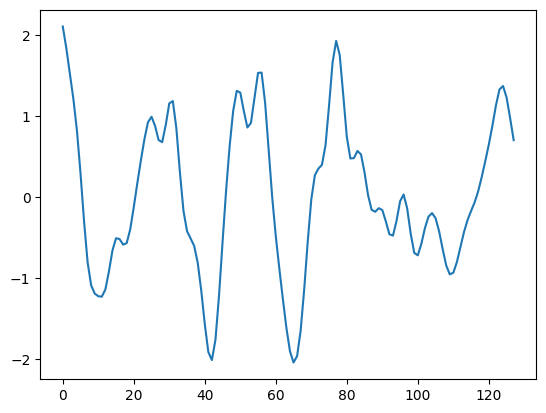

In [2]:
scaler = RegionWiseStandardizer()
x_train_region_wise_norm = scaler.fit_transform(x_train, y_train)
x_val_region_wise_norm = scaler.transform(x_val, y_val)
x_test_region_wise_norm = scaler.transform(x_test, y_test)

state = 8 # MI=1 ; Rest=-1
index = 1
plt.plot(x_test_region_wise_norm[np.where(y_test==state)[0]][index])

In [3]:
region  = 45

Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]

stds = []
mns = []
maxs_abs = []
for trace in x_test_region_wise_norm[np.where(y_test==-region)[0]]:
    # REST traces
    #print(trace.std(), trace.mean())
    stds.append(trace.std())
    mns.append(trace.mean())
    maxs_abs.append(max(trace.max(),-trace.min()))

for trace in x_test_region_wise_norm[np.where(y_test==region)[0]]:
    # MI traces
    #print(trace.std(), trace.mean())
    stds.append(trace.std())
    mns.append(trace.mean())
    maxs_abs.append(max(trace.max(),-trace.min()))

Text(0.5, 1.0, 'Means')

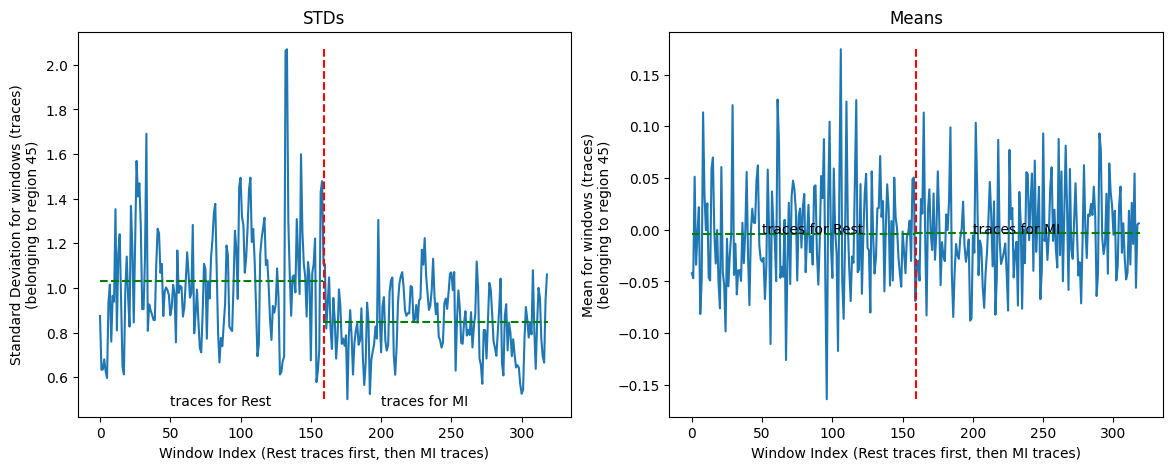

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# -------- Panel 1: STDs --------
axes[0].plot(stds)
axes[0].vlines(len(stds)/2, ymin=min(stds), ymax=max(stds),colors='r', linestyles='--')
axes[0].hlines(np.mean(stds[:len(stds)//2]), xmin=0, xmax=len(stds)//2,colors='g', linestyles='--')
axes[0].hlines(np.mean(stds[len(stds)//2:]),xmin=len(stds)//2, xmax=len(stds), colors='g', linestyles='--')
axes[0].set_ylabel(f"Standard Deviation for windows (traces)\n(belonging to region {region})")
axes[0].set_xlabel("Window Index (Rest traces first, then MI traces)")
axes[0].text(50, 0.475, "traces for Rest")
axes[0].text(200, 0.475, "traces for MI")
axes[0].set_title("STDs")

# -------- Panel 2: Means (mns) --------
axes[1].plot(mns)
axes[1].vlines(len(mns)/2, ymin=min(mns), ymax=max(mns),colors='r', linestyles='--')
axes[1].hlines(np.mean(mns[:len(mns)//2]),xmin=0, xmax=len(mns)//2, colors='g', linestyles='--')
axes[1].hlines(np.mean(mns[len(mns)//2:]), xmin=len(mns)//2, xmax=len(mns), colors='g', linestyles='--')
axes[1].set_ylabel(f"Mean for windows (traces)\n(belonging to region {region})")
axes[1].set_xlabel("Window Index (Rest traces first, then MI traces)")
axes[1].text(50, np.mean(mns), "traces for Rest")
axes[1].text(200, np.mean(mns), "traces for MI")
axes[1].set_title("Means")




Text(200, 2.390303206688777, 'traces for MI')

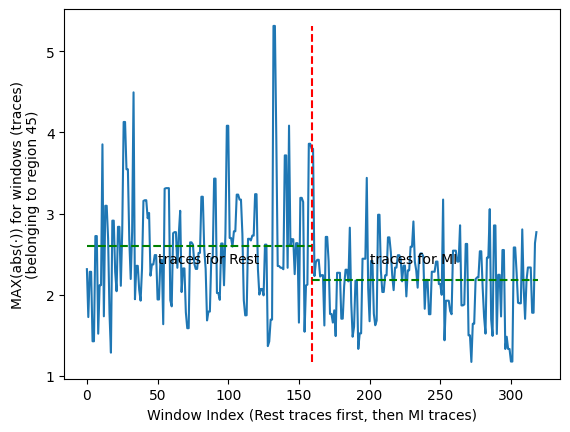

In [ ]:

plt.plot(maxs_abs)
plt.vlines(len(maxs_abs)/2, ymin=min(maxs_abs), ymax=max(maxs_abs),colors='r', linestyles='--')
plt.hlines(np.mean(maxs_abs[:len(maxs_abs)//2]),xmin=0, xmax=len(maxs_abs)//2, colors='g', linestyles='--')
plt.hlines(np.mean(maxs_abs[len(maxs_abs)//2:]), xmin=len(maxs_abs)//2, xmax=len(maxs_abs), colors='g', linestyles='--')
plt.ylabel(f"MAX(abs(·)) for windows (traces)\n(belonging to region {region})")
plt.xlabel("Window Index (Rest traces first, then MI traces)")
plt.text(50, np.mean(maxs_abs), "traces for Rest")
plt.text(200, np.mean(maxs_abs), "traces for MI")
plt.title("MAX(abs(trace))")



### Trace-wise 

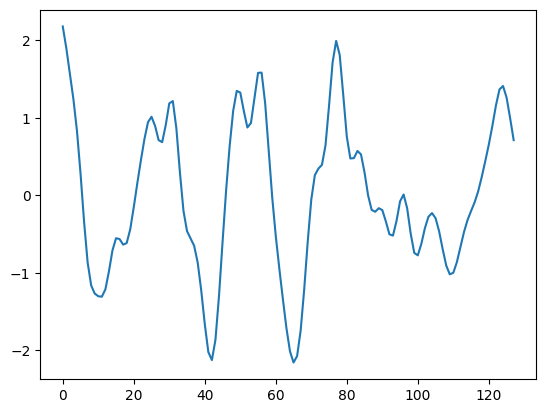

In [2]:
scaler = TraceWiseStandardizer(method='zscore')
x_test_trace_wise_norm = scaler(x_test)
x_test_trace_wise_norm[0].std()

state = 8 # MI=1 ; Rest=-1
index = 1
plt.plot(x_test_trace_wise_norm[np.where(y_test==state)[0]][index])

In [4]:
scaler = TraceWiseStandardizer(method='zscore')
x_test_trace_wise_norm = scaler(x_test)
x_test_trace_wise_norm[0].std()



np.float64(1.0)

In [5]:
region  = 45

Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]

stds = []
mns = []
maxs_abs = []
for trace in x_test_trace_wise_norm[np.where(y_test==-region)[0]]:
    # REST traces
    #print(trace.std(), trace.mean())
    stds.append(trace.std())
    mns.append(trace.mean())
    maxs_abs.append(max(trace.max(),-trace.min()))

for trace in x_test_trace_wise_norm[np.where(y_test==region)[0]]:
    # MI traces
    #print(trace.std(), trace.mean())
    stds.append(trace.std())
    mns.append(trace.mean())
    maxs_abs.append(max(trace.max(),-trace.min()))

In [6]:
trace.std()

np.float64(1.0)

Text(0.5, 1.0, 'Means')

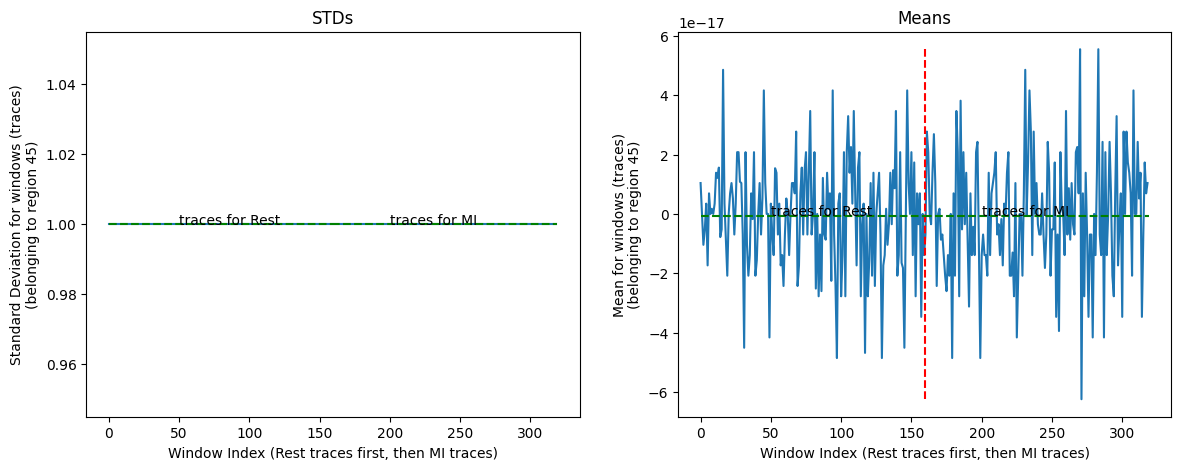

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# -------- Panel 1: STDs --------
axes[0].plot(stds)
axes[0].vlines(len(stds)/2, ymin=min(stds), ymax=max(stds),colors='r', linestyles='--')
axes[0].hlines(np.mean(stds[:len(stds)//2]), xmin=0, xmax=len(stds)//2,colors='g', linestyles='--')
axes[0].hlines(np.mean(stds[len(stds)//2:]),xmin=len(stds)//2, xmax=len(stds), colors='g', linestyles='--')
axes[0].set_ylabel(f"Standard Deviation for windows (traces)\n(belonging to region {region})")
axes[0].set_xlabel("Window Index (Rest traces first, then MI traces)")
axes[0].text(50, 1, "traces for Rest")
axes[0].text(200,1, "traces for MI")
axes[0].set_title("STDs")

# -------- Panel 2: Means (mns) --------
axes[1].plot(mns)
axes[1].vlines(len(mns)/2, ymin=min(mns), ymax=max(mns),colors='r', linestyles='--')
axes[1].hlines(np.mean(mns[:len(mns)//2]),xmin=0, xmax=len(mns)//2, colors='g', linestyles='--')
axes[1].hlines(np.mean(mns[len(mns)//2:]), xmin=len(mns)//2, xmax=len(mns), colors='g', linestyles='--')
axes[1].set_ylabel(f"Mean for windows (traces)\n(belonging to region {region})")
axes[1].set_xlabel("Window Index (Rest traces first, then MI traces)")
axes[1].text(50, np.mean(mns), "traces for Rest")
axes[1].text(200, np.mean(mns), "traces for MI")
axes[1].set_title("Means")




Text(0.5, 1.0, 'MAX(abs(trace))')

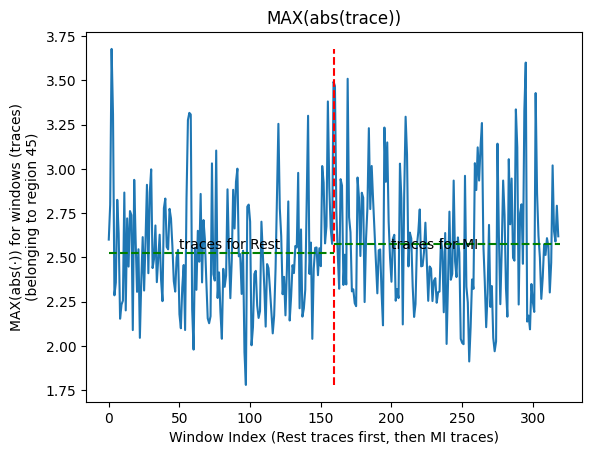

In [10]:

plt.plot(maxs_abs)
plt.vlines(len(maxs_abs)/2, ymin=min(maxs_abs), ymax=max(maxs_abs),colors='r', linestyles='--')
plt.hlines(np.mean(maxs_abs[:len(maxs_abs)//2]),xmin=0, xmax=len(maxs_abs)//2, colors='g', linestyles='--')
plt.hlines(np.mean(maxs_abs[len(maxs_abs)//2:]), xmin=len(maxs_abs)//2, xmax=len(maxs_abs), colors='g', linestyles='--')
plt.ylabel(f"MAX(abs(·)) for windows (traces)\n(belonging to region {region})")
plt.xlabel("Window Index (Rest traces first, then MI traces)")
plt.text(50, np.mean(maxs_abs), "traces for Rest")
plt.text(200, np.mean(maxs_abs), "traces for MI")
plt.title("MAX(abs(trace))")

# TEMP TESTS

In [ ]:
# Load model
from Deep_Library_BCI import MultiTaskModel
import tensorflow.keras as keras
model = MultiTaskModel(input_shape=(128,1), use_classifier=True, use_decoder=False)
model.build(input_shape=(128,1))
model.load_weights("../_Deep_Learning/Models_trained/2026-01-23_21_51_04_First_Try/model.weights.h5")


In [31]:
import pandas as pd 
import numpy as np
aggr = pd.read_pickle("../_Deep_Learning/Models_trained/2026-01-24-11_51_50_First_Try/aggregated_region_performance.pkl")
acc = aggr['accuracy']

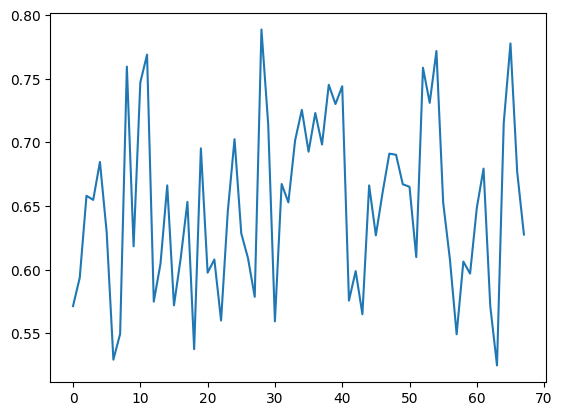

In [34]:
plt.plot(acc.apply(np.mean))